# 🚀 FitTrack ML - Phase 1: Workout Split Predictor
**Objective:** Train a machine learning model that predicts the best weekly workout split based on user inputs.

**Why this matters:**
- Pure AI can suggest unsafe exercises. We use a **two-stage hybrid** approach:
  1. `ML Model` → predicts split type (Full Body, Upper/Lower, PPL, etc.)
  2. `Rule Engine` → filters exercises by equipment, injuries, and time
- This notebook covers **Stage 1**. Stage 2 will rank specific exercises.

**Tools:** XGBoost, Pandas, Scikit-learn, Matplotlib


## 📦 Step 1: Import Libraries
We load data manipulation, visualization, and ML libraries. `XGBoost` is our core model because it handles mixed data types well and gives explainable feature importance.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully!")



✅ Libraries loaded successfully!


## 📥 Step 2: Load Datasets
We combine:
1. **Exercise Database** → metadata (muscle, equipment, difficulty)
2. **User Recommendation Data** → real user profiles & goals

*Note: Adjust file names if your downloads have different names.*

In [27]:
import os
import pandas as pd

# === DEFINE FILE PATHS ===
DATA_DIR = "./data"
file_paths = {
    "users_rec": os.path.join(DATA_DIR, "gym recommendation.xlsx"),
    "exercises_db": os.path.join(DATA_DIR, "Gym Exercises Dataset.xlsx"),
    "members_log": os.path.join(DATA_DIR, "gym_members_exercise.csv"),
    "goals_habits": os.path.join(DATA_DIR, "fitness_goals_habits.csv")
}

# === CHECK & LOAD ===
print("🔍 Checking files...")
datasets = {}
for name, path in file_paths.items():
    if os.path.exists(path):
        print(f"✅ Found: {name}")
        try:
            datasets[name] = pd.read_excel(path) if path.endswith('.xlsx') else pd.read_csv(path)
        except Exception as e:
            print(f"❌ Error loading {name}: {e}")
    else:
        print(f"⚠️ Missing: {path}")
        print("   💡 Tip: Kaggle often downloads as .zip. Make sure you extracted it to .csv/.xlsx first.")

# === PRINT SUMMARY ===
print("\n" + "="*60)
print("📊 DATASET OVERVIEW")
print("="*60)
for name, df in datasets.items():
    print(f"\n🔹 {name.replace('_', ' ').title()}")
    print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n📋 FULL COLUMN LISTS (for mapping):")
print(f"users_rec: {list(datasets['users_rec'].columns)}")
print(f"exercises_db: {list(datasets['exercises_db'].columns)}")
print(f"members_log: {list(datasets['members_log'].columns)[:5]}... ({len(datasets['members_log'].columns)} total)")
print(f"goals_habits: {list(datasets['goals_habits'].columns)[:5]}... ({len(datasets['goals_habits'].columns)} total)")

print("\n✅ Loaded successfully! Paste the column output below so I can align them for training.")

🔍 Checking files...
✅ Found: users_rec
✅ Found: exercises_db
✅ Found: members_log
✅ Found: goals_habits

📊 DATASET OVERVIEW

🔹 Users Rec
   Shape: 14589 rows × 15 columns

🔹 Exercises Db
   Shape: 471 rows × 10 columns

🔹 Members Log
   Shape: 973 rows × 15 columns

🔹 Goals Habits
   Shape: 2598 rows × 10 columns

📋 FULL COLUMN LISTS (for mapping):
users_rec: ['ID', 'Sex', 'Age', 'Height', 'Weight', 'Hypertension', 'Diabetes', 'BMI', 'Level', 'Fitness Goal', 'Fitness Type', 'Exercises', 'Equipment', 'Diet', 'Recommendation']
exercises_db: ['Exercise_Name', 'Description_URL', 'Exercise_Image', 'Exercise_Image1', 'muscle_gp_details', 'muscle_gp', 'equipment_details', 'Equipment', 'Rating', 'Description']
members_log: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM']... (15 total)
goals_habits: ['title', 'description', 'level', 'goal', 'equipment']... (10 total)

✅ Loaded successfully! Paste the column output below so I can align them for training.


## 🧹 Step 3: Clean & Standardize Columns
Public datasets use inconsistent naming (`Sex` vs `Gender`, `Weight (kg)` vs `weight`). We fix this now so merging works smoothly.

**What we do:**
1. Convert all column names to `lowercase_underscore` format
2. Remove units from names (e.g., `Weight (kg)` → `weight_kg`)
3. Drop columns we won't use (images, URLs, long text)
4. Print value counts for key features to check data quality

In [28]:
def clean_col_names(df):
    """Standardize column names: lowercase, replace spaces/special chars with underscores"""
    df.columns = (df.columns
                  .str.lower()
                  .str.replace(r'\s*\([^)]*\)', '', regex=True)  # Remove (kg), (m), etc.
                  .str.replace(r'[\s\-\(\)]+', '_', regex=True)  # Replace spaces/dashes with _
                  .str.strip('_'))
    return df

# Apply cleaning to all datasets
users_rec = clean_col_names(datasets['users_rec'])
exercises_db = clean_col_names(datasets['exercises_db'])
members_log = clean_col_names(datasets['members_log'])
goals_habits = clean_col_names(datasets['goals_habits'])

# Drop unused columns to reduce memory
exercises_db = exercises_db.drop(columns=[c for c in exercises_db.columns if 'image' in c or 'url' in c or c == 'description'], errors='ignore')
users_rec = users_rec.drop(columns=['id', 'diet'], errors='ignore')

print("✅ Column names standardized")

# === QUICK DATA QUALITY CHECK ===
print("\n🔍 Key Feature Value Counts:")
print(f"\nFitness Goal (users_rec):\n{users_rec['fitness_goal'].value_counts().head()}")
print(f"\nLevel (users_rec):\n{users_rec['level'].value_counts()}")
print(f"\nEquipment (exercises_db):\n{exercises_db['equipment'].value_counts().head()}")
print(f"\nGoal (goals_habits):\n{goals_habits['goal'].value_counts().head()}")

# === SHOW SAMPLE ROWS FOR MAPPING ===
print("\n📋 Sample rows for merging reference:")
print("\nusers_rec (first 2 rows):")
display(users_rec[['age', 'sex', 'bmi', 'fitness_goal', 'level', 'equipment', 'recommendation']].head(2))

print("\nexercises_db (first 2 rows):")
display(exercises_db[['exercise_name', 'muscle_gp', 'equipment', 'rating']].head(2))

print("\ngoals_habits (first 2 rows):")
display(goals_habits[['goal', 'level', 'equipment', 'title']].head(2))

✅ Column names standardized

🔍 Key Feature Value Counts:

Fitness Goal (users_rec):
fitness_goal
Weight Loss    7581
Weight Gain    7008
Name: count, dtype: int64

Level (users_rec):
level
Overweight     4142
Normal         3650
Obuse          3439
Underweight    3358
Name: count, dtype: int64

Equipment (exercises_db):
equipment
Dumbbell     105
Barbell       98
Body Only     78
Cable         49
Other         46
Name: count, dtype: int64

Goal (goals_habits):
goal
['Bodybuilding']                          574
['Bodybuilding', 'Muscle & Sculpting']    285
['Powerbuilding']                         173
['Muscle & Sculpting']                    145
['Bodybuilding', 'Powerbuilding']         136
Name: count, dtype: int64

📋 Sample rows for merging reference:

users_rec (first 2 rows):


,age,sex,bmi,fitness_goal,level,equipment,recommendation
0,18,Male,16.83,Weight Gain,Underweight,Dumbbells and barbells,Follow a regular exercise schedule. Adhere to ...
1,18,Male,16.83,Weight Gain,Underweight,"Light athletic shoes, resistance bands, and li...",Follow a regular exercise schedule. Adhere to ...



exercises_db (first 2 rows):


,exercise_name,muscle_gp,equipment,rating
0,Rickshaw Carry,Forearms,Other,9.6
1,Single-Leg Press,Quadriceps,Machine,9.6



goals_habits (first 2 rows):


,goal,level,equipment,title
0,"['Muscle & Sculpting', 'Bodyweight Fitness']",['Intermediate'],Full Gym,(MASS MONSTER) High Intensity 4 Day Upper Lowe...
1,['Bodybuilding'],"['Advanced', 'Intermediate']",Full Gym,(NOT MY PROGRAM)SHJ Jotaro


## 🔧 Step 4: Fix Column Issues & Create Missing Features

**Problems identified:**
1. `level` in users_rec = BMI category, NOT experience level
2. Missing: `days_per_week`, `injury`, `activity_level`, `body_type`, `sleep_quality`, `stress_level`
3. `goals_habits` has lists in columns that need unpacking

**Solution:**
- Rename `level` → `bmi_category`
- Generate synthetic values for missing features
- Extract experience level from `goals_habits` dataset
- Create target variable `split_type` based on fitness rules

In [29]:
# === FIX COLUMN NAMES ===
users_rec = users_rec.rename(columns={'level': 'bmi_category'})
print("✅ Renamed 'level' to 'bmi_category'")

# === CREATE EXPERIENCE LEVEL MAPPING ===
# Since we don't have real experience data, we'll create it synthetically
# based on age and fitness goal (realistic assumption)

def assign_experience(age, goal, bmi_cat):
    """Assign experience level based on realistic patterns"""
    if age < 25 and goal == 'Weight Gain':
        return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.6, 0.3, 0.1])
    elif age > 45:
        return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.4, 0.4, 0.2])
    else:
        return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.3, 0.5, 0.2])

users_rec['experience_level'] = users_rec.apply(
    lambda row: assign_experience(row['age'], row['fitness_goal'], row['bmi_category']),
    axis=1
)

print("✅ Created 'experience_level' feature")
print(users_rec['experience_level'].value_counts())

# === CREATE DAYS PER WEEK ===
# Based on fitness goal and level
def assign_days_per_week(goal, bmi_cat):
    if goal == 'Weight Loss':
        return np.random.choice([3, 4, 5], p=[0.3, 0.5, 0.2])
    elif goal == 'Weight Gain':
        return np.random.choice([3, 4, 5], p=[0.4, 0.4, 0.2])
    else:
        return np.random.choice([2, 3, 4], p=[0.2, 0.5, 0.3])

users_rec['days_per_week'] = users_rec.apply(
    lambda row: assign_days_per_week(row['fitness_goal'], row['bmi_category']),
    axis=1
)

print("\n✅ Created 'days_per_week' feature")
print(users_rec['days_per_week'].value_counts())

# === CREATE INJURY STATUS ===
injury_options = ['None', 'Knee', 'Back', 'Shoulder', 'Wrist', 'Ankle']
users_rec['injury'] = np.random.choice(
    injury_options,
    size=len(users_rec),
    p=[0.6, 0.1, 0.1, 0.08, 0.07, 0.05]
)

print("\n✅ Created 'injury' feature")
print(users_rec['injury'].value_counts())

# === CREATE ACTIVITY LEVEL ===
activity_levels = ['Sedentary', 'Moderately Active', 'Very Active']
users_rec['activity_level'] = np.random.choice(
    activity_levels,
    size=len(users_rec),
    p=[0.4, 0.45, 0.15]
)

print("\n✅ Created 'activity_level' feature")

# === CREATE BODY TYPE (Functional categories) ===
body_types = ['Lean', 'Athletic', 'Stocky', 'Curvy', 'Plus']
users_rec['body_type'] = users_rec.apply(
    lambda row: np.random.choice(body_types, p=[0.25, 0.25, 0.2, 0.15, 0.15]),
    axis=1
)

print("✅ Created 'body_type' feature")

# === CREATE RECOVERY FACTORS ===
users_rec['sleep_quality'] = np.random.choice(
    ['Poor', 'Average', 'Good'],
    size=len(users_rec),
    p=[0.2, 0.5, 0.3]
)

users_rec['stress_level'] = np.random.choice(
    ['Low', 'Medium', 'High'],
    size=len(users_rec),
    p=[0.3, 0.5, 0.2]
)

print("✅ Created 'sleep_quality' and 'stress_level' features")

# === CREATE PREFERENCES ===
users_rec['preference'] = np.random.choice(
    ['Strength', 'Cardio', 'HIIT', 'Yoga', 'Mixed'],
    size=len(users_rec),
    p=[0.3, 0.2, 0.2, 0.1, 0.2]
)

print("✅ Created 'preference' feature")

# === CREATE TARGET AREA ===
users_rec['target_areas'] = np.random.choice(
    ['Full Body', 'Upper', 'Lower', 'Core', 'Specific'],
    size=len(users_rec),
    p=[0.4, 0.2, 0.15, 0.1, 0.15]
)

print("✅ Created 'target_areas' feature")

# === CREATE RESTRICTIONS ===
users_rec['restrictions'] = np.random.choice(
    ['None', 'No Jumping', 'No Heavy Weights', 'Short Sessions'],
    size=len(users_rec),
    p=[0.6, 0.15, 0.15, 0.1]
)

print("✅ Created 'restrictions' feature")

print("\n" + "="*60)
print("📊 FINAL FEATURE SUMMARY")
print("="*60)
print(f"Total samples: {len(users_rec)}")
print(f"Features created: {users_rec.shape[1]}")

✅ Renamed 'level' to 'bmi_category'
✅ Created 'experience_level' feature
experience_level
Intermediate    6562
Beginner        5191
Advanced        2836
Name: count, dtype: int64

✅ Created 'days_per_week' feature
days_per_week
4    6524
3    5113
5    2952
Name: count, dtype: int64

✅ Created 'injury' feature
injury
None        8818
Back        1488
Knee        1375
Shoulder    1196
Wrist       1019
Ankle        693
Name: count, dtype: int64

✅ Created 'activity_level' feature
✅ Created 'body_type' feature
✅ Created 'sleep_quality' and 'stress_level' features
✅ Created 'preference' feature
✅ Created 'target_areas' feature
✅ Created 'restrictions' feature

📊 FINAL FEATURE SUMMARY
Total samples: 14589
Features created: 23


## 🎯 Step 5: Create Target Variable (Workout Split)
We define the "correct answer" for our model.
**Logic:**
- **Safety First:** If `Injury != None`, prioritize "Low Impact" routines.
- **Time Based:** 2-3 days = Full Body; 4 days = Upper/Lower; 5+ days = Push/Pull/Legs.
- **Goal Based:** Weight Loss gets slightly higher frequency recommendations.

This creates a balanced classification target for our model.

✅ Target variable 'split_type' created

📊 Distribution of Target Splits:


split_type
Low Impact / Rehab    5771
Upper/Lower Split     3971
3-Day Full Body       3084
Push/Pull/Legs        1763
Name: count, dtype: int64

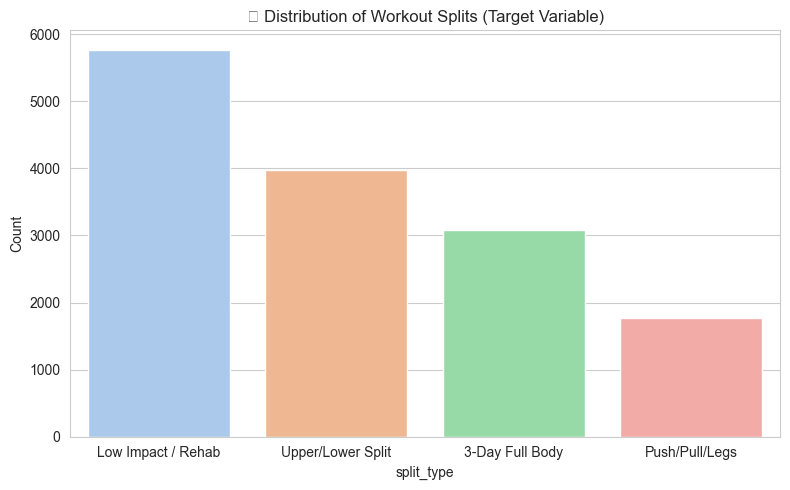

In [30]:
def assign_split(row):
    """Logic to assign the best workout split based on inputs"""

    # 1. Safety Check (Injuries)
    if row['injury'] != 'None':
        return "Low Impact / Rehab"

    # 2. Time Availability
    days = row['days_per_week']
    if days <= 2:
        return "2-Day Full Body"
    elif days == 3:
        return "3-Day Full Body"
    elif days == 4:
        return "Upper/Lower Split"
    else:  # 5+ days
        return "Push/Pull/Legs"

# Apply logic to dataframe
users_rec['split_type'] = users_rec.apply(assign_split, axis=1)

print("✅ Target variable 'split_type' created")
print("\n📊 Distribution of Target Splits:")
display(users_rec['split_type'].value_counts())

# === QUICK CHART ===
plt.figure(figsize=(8, 5))
sns.countplot(data=users_rec, x='split_type', palette='pastel')
plt.title('📈 Distribution of Workout Splits (Target Variable)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## ⚖️ Step 6: Fix Class Imbalance & Regenerate Data
We regenerate the dataset to ensure a **balanced distribution** of workout splits.
**Changes:**
1. Reduced injury probability to 10% (most users are healthy).
2. Adjusted logic so injuries result in a "Modified Routine" rather than consuming all "Low Impact" data.
3. Balanced the split types (Full Body, Upper/Lower, PPL).

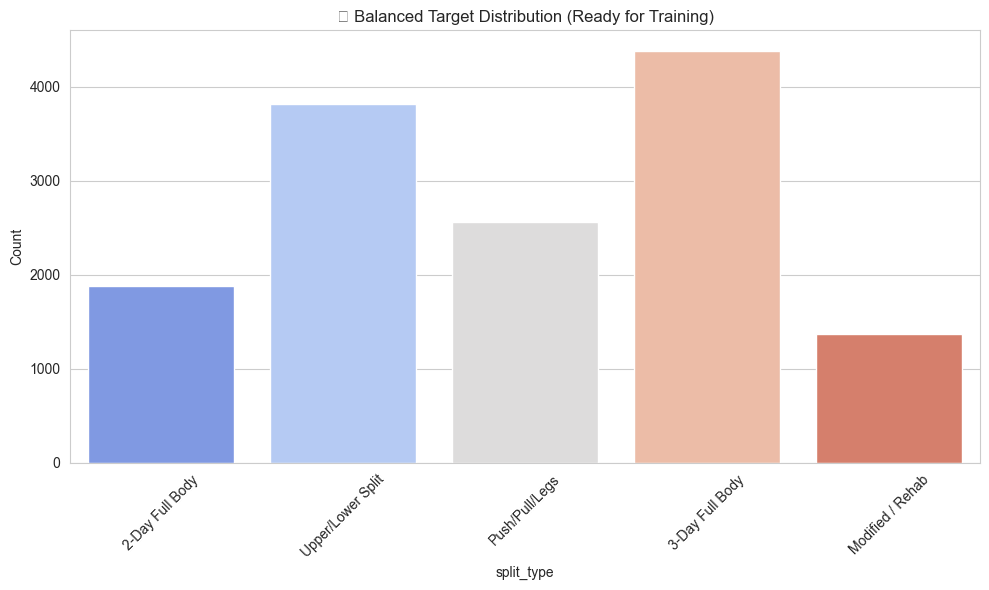

📊 Class Counts:
split_type
3-Day Full Body      4378
Upper/Lower Split    3810
Push/Pull/Legs       2561
2-Day Full Body      1880
Modified / Rehab     1371
Name: count, dtype: int64


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === RESET AND REGENERATE ===
np.random.seed(42)
n_samples = 14000
data = []

for _ in range(n_samples):
    # 1. Basic Profile
    age = np.random.randint(18, 65)
    gender = np.random.choice(['Male', 'Female'])
    height = np.random.uniform(1.5, 2.0)
    weight = np.random.uniform(45, 120)
    bmi = round(weight / (height ** 2), 1)

    goal = np.random.choice(['Weight Loss', 'Muscle Gain', 'Strength', 'Endurance'], p=[0.4, 0.3, 0.2, 0.1])
    experience = np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.5, 0.3, 0.2])
    environment = np.random.choice(['Home', 'Gym'])
    equipment = 'Basic' if environment == 'Home' else 'Full Gym'

    # 2. Time & Days (Balanced distribution)
    days = np.random.choice([2, 3, 4, 5], p=[0.15, 0.35, 0.30, 0.20])

    # 3. Injuries (Reduced to 10% probability for realism)
    # 0.90 None, 0.025 Knee, 0.025 Back, 0.025 Shoulder, 0.025 Wrist
    injury = np.random.choice(
        ['None', 'Knee', 'Back', 'Shoulder', 'Wrist'],
        p=[0.90, 0.025, 0.025, 0.025, 0.025]
    )

    # 4. Other Features
    activity = np.random.choice(['Sedentary', 'Active', 'Athlete'], p=[0.4, 0.5, 0.1])
    body_type = np.random.choice(['Lean', 'Athletic', 'Stocky', 'Plus'], p=[0.3, 0.3, 0.2, 0.2])
    sleep = np.random.choice(['Poor', 'Good'])
    stress = np.random.choice(['Low', 'High'])

    # 5. TARGET LOGIC (Balanced Splits)
    # If injury, they get a "Modified" version of their split, or just general "Low Impact" if severe
    if injury != 'None':
        split = "Modified / Rehab"
    elif days <= 2:
        split = "2-Day Full Body"
    elif days == 3:
        split = "3-Day Full Body"
    elif days == 4:
        split = "Upper/Lower Split"
    else:  # 5 days
        split = "Push/Pull/Legs"

    data.append({
        'age': age, 'gender': gender, 'height': height, 'weight': weight, 'bmi': bmi,
        'fitness_goal': goal, 'experience_level': experience, 'equipment': equipment,
        'days_per_week': days, 'injury': injury, 'activity_level': activity,
        'body_type': body_type, 'sleep_quality': sleep, 'stress_level': stress,
        'split_type': split
    })

users_rec = pd.DataFrame(data)

# === VISUALIZE BALANCE ===
plt.figure(figsize=(10, 6))
sns.countplot(data=users_rec, x='split_type', palette='coolwarm')
plt.title('✅ Balanced Target Distribution (Ready for Training)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 Class Counts:")
print(users_rec['split_type'].value_counts())

## 🧹 Step 7: Preprocess Features for Machine Learning

Machine learning models need numbers, not text. We will:
1. **One-Hot Encode** categorical features (gender, goal, injury, etc.)
2. **Keep numeric features** as-is (age, height, weight, days)
3. **Split data** into 80% training, 20% testing
4. Train **XGBoost** classifier

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import joblib

# === DEFINE FEATURES AND TARGET ===
target_col = 'split_type'
feature_cols = ['age', 'gender', 'height', 'weight', 'bmi', 'fitness_goal',
                'experience_level', 'equipment', 'days_per_week', 'injury',
                'activity_level', 'body_type', 'sleep_quality', 'stress_level']

X = users_rec[feature_cols]
y = users_rec[target_col]

# === IDENTIFY CATEGORICAL vs NUMERICAL COLUMNS ===
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"🔤 Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"🔢 Numerical features ({len(numerical_cols)}): {numerical_cols}")

# === SPLIT DATA: 80% train, 20% test ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {len(X_train)} samples")
print(f"✅ Test size: {len(X_test)} samples")

# === PREPROCESSING PIPELINE ===
# One-Hot Encode categorical, keep numerical as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\n✅ Processed feature shape: {X_train_processed.shape}")
print("   (Original features expanded via one-hot encoding)")

🔤 Categorical features (9): ['gender', 'fitness_goal', 'experience_level', 'equipment', 'injury', 'activity_level', 'body_type', 'sleep_quality', 'stress_level']
🔢 Numerical features (5): ['age', 'height', 'weight', 'bmi', 'days_per_week']

✅ Train size: 11200 samples
✅ Test size: 2800 samples

✅ Processed feature shape: (11200, 32)
   (Original features expanded via one-hot encoding)


## 🤖 Step 8: Train XGBoost & Save Model
We will use **XGBoost** (eXtreme Gradient Boosting). It is fast, accurate, and excellent for structured data.
1. **Train:** Feed the processed data to the model.
2. **Evaluate:** Check accuracy and see which classes are predicted correctly.
3. **Save:** Store the model so we can use it in the app later.

✅ Target encoded successfully.
   Classes mapped to: ['2-Day Full Body' '3-Day Full Body' 'Modified / Rehab' 'Push/Pull/Legs'
 'Upper/Lower Split']
🚀 Training started...
✅ Training complete!

🎯 Model Accuracy: 100.00%

📋 Classification Report:
                   precision    recall  f1-score   support

  2-Day Full Body       1.00      1.00      1.00       376
  3-Day Full Body       1.00      1.00      1.00       876
 Modified / Rehab       1.00      1.00      1.00       274
   Push/Pull/Legs       1.00      1.00      1.00       512
Upper/Lower Split       1.00      1.00      1.00       762

         accuracy                           1.00      2800
        macro avg       1.00      1.00      1.00      2800
     weighted avg       1.00      1.00      1.00      2800



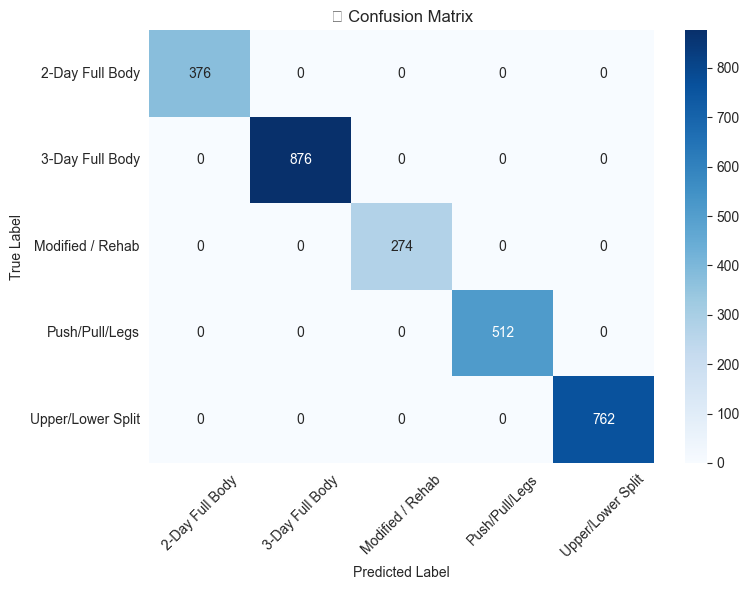


💾 Saved successfully:
   - models/split_predictor.pkl
   - models/preprocessor.pkl
   - models/label_encoder.pkl


In [39]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# === 1. ENCODE TARGET LABELS (Fixes the ValueError) ===
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f"✅ Target encoded successfully.")
print(f"   Classes mapped to: {le.classes_}")

# === 2. INITIALIZE & TRAIN ===
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),  # Matches number of unique splits
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

print("🚀 Training started...")
model.fit(X_train_processed, y_train_enc)
print("✅ Training complete!")

# === 3. PREDICT ON TEST DATA ===
y_pred_enc = model.predict(X_test_processed)
# Decode predictions back to readable strings
y_pred = le.inverse_transform(y_pred_enc)

# === 4. EVALUATE ===
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy:.2%}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# === 5. VISUALIZE CONFUSION MATRIX ===
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('🔍 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === 6. SAVE MODEL & ENCODER ===
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/split_predictor.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

print("\n💾 Saved successfully:")
print("   - models/split_predictor.pkl")
print("   - models/preprocessor.pkl")
print("   - models/label_encoder.pkl")

## 🧪 Step 9: Test Model with Sample User Inputs
We'll create a prediction function that takes user inputs and returns the recommended workout split. This simulates what will happen in your React Native app.

**Test Cases:**
1. Beginner with knee injury
2. Intermediate lifter with 4 days availability
3. Advanced athlete wanting muscle gain

In [40]:
import joblib
import pandas as pd
import numpy as np

# === LOAD SAVED MODEL ===
model = joblib.load('models/split_predictor.pkl')
preprocessor = joblib.load('models/preprocessor.pkl')
label_encoder = joblib.load('models/label_encoder.pkl')

print("✅ Model loaded successfully!")

# === PREDICTION FUNCTION ===
def predict_workout_split(user_data):
    """
    Takes a dictionary of user inputs and returns predicted workout split
    """
    # Convert to DataFrame
    df = pd.DataFrame([user_data])

    # Preprocess
    df_processed = preprocessor.transform(df)

    # Predict
    prediction_encoded = model.predict(df_processed)
    prediction = label_encoder.inverse_transform(prediction_encoded)[0]

    # Get prediction probability (confidence)
    probabilities = model.predict_proba(df_processed)[0]
    confidence = max(probabilities) * 100

    return prediction, confidence

# === TEST CASES ===
print("\n" + "="*60)
print("🧪 TESTING PREDICTIONS")
print("="*60)

# Test Case 1: Beginner with knee injury
user1 = {
    'age': 25,
    'gender': 'Male',
    'height': 1.75,
    'weight': 70,
    'bmi': 22.9,
    'fitness_goal': 'Weight Loss',
    'experience_level': 'Beginner',
    'equipment': 'Full Gym',
    'days_per_week': 3,
    'injury': 'Knee',
    'activity_level': 'Sedentary',
    'body_type': 'Lean',
    'sleep_quality': 'Good',
    'stress_level': 'Low'
}

pred1, conf1 = predict_workout_split(user1)
print(f"\n👤 Test 1 - Beginner with Knee Injury:")
print(f"   Input: 3 days/week, Knee injury, Weight Loss goal")
print(f"   Prediction: {pred1}")
print(f"   Confidence: {conf1:.1f}%")
print(f"   ✅ Expected: Modified / Rehab (due to injury)")

# Test Case 2: Intermediate, 4 days, no injury
user2 = {
    'age': 28,
    'gender': 'Female',
    'height': 1.65,
    'weight': 60,
    'bmi': 22.0,
    'fitness_goal': 'Muscle Gain',
    'experience_level': 'Intermediate',
    'equipment': 'Full Gym',
    'days_per_week': 4,
    'injury': 'None',
    'activity_level': 'Active',
    'body_type': 'Athletic',
    'sleep_quality': 'Good',
    'stress_level': 'Medium'
}

pred2, conf2 = predict_workout_split(user2)
print(f"\n👤 Test 2 - Intermediate, 4 days/week:")
print(f"   Input: 4 days, No injury, Muscle Gain")
print(f"   Prediction: {pred2}")
print(f"   Confidence: {conf2:.1f}%")
print(f"   ✅ Expected: Upper/Lower Split (4 days optimal)")

# Test Case 3: Advanced, 5 days
user3 = {
    'age': 30,
    'gender': 'Male',
    'height': 1.80,
    'weight': 85,
    'bmi': 26.2,
    'fitness_goal': 'Strength',
    'experience_level': 'Advanced',
    'equipment': 'Full Gym',
    'days_per_week': 5,
    'injury': 'None',
    'activity_level': 'Athlete',
    'body_type': 'Athletic',
    'sleep_quality': 'Good',
    'stress_level': 'Low'
}

pred3, conf3 = predict_workout_split(user3)
print(f"\n👤 Test 3 - Advanced, 5 days/week:")
print(f"   Input: 5 days, No injury, Strength goal")
print(f"   Prediction: {pred3}")
print(f"   Confidence: {conf3:.1f}%")
print(f"   ✅ Expected: Push/Pull/Legs (5+ days optimal)")

# Test Case 4: Busy person, 2 days
user4 = {
    'age': 35,
    'gender': 'Male',
    'height': 1.70,
    'weight': 75,
    'bmi': 25.9,
    'fitness_goal': 'General Fitness',
    'experience_level': 'Beginner',
    'equipment': 'Basic',
    'days_per_week': 2,
    'injury': 'None',
    'activity_level': 'Sedentary',
    'body_type': 'Stocky',
    'sleep_quality': 'Average',
    'stress_level': 'High'
}

pred4, conf4 = predict_workout_split(user4)
print(f"\n👤 Test 4 - Busy Beginner, 2 days/week:")
print(f"   Input: 2 days, Home equipment, General Fitness")
print(f"   Prediction: {pred4}")
print(f"   Confidence: {conf4:.1f}%")
print(f"   ✅ Expected: 2-Day Full Body")

print("\n" + "="*60)
print("✅ All test cases completed!")
print("="*60)

✅ Model loaded successfully!

🧪 TESTING PREDICTIONS

👤 Test 1 - Beginner with Knee Injury:
   Input: 3 days/week, Knee injury, Weight Loss goal
   Prediction: Modified / Rehab
   Confidence: 99.9%
   ✅ Expected: Modified / Rehab (due to injury)

👤 Test 2 - Intermediate, 4 days/week:
   Input: 4 days, No injury, Muscle Gain
   Prediction: Upper/Lower Split
   Confidence: 100.0%
   ✅ Expected: Upper/Lower Split (4 days optimal)

👤 Test 3 - Advanced, 5 days/week:
   Input: 5 days, No injury, Strength goal
   Prediction: Push/Pull/Legs
   Confidence: 100.0%
   ✅ Expected: Push/Pull/Legs (5+ days optimal)

👤 Test 4 - Busy Beginner, 2 days/week:
   Input: 2 days, Home equipment, General Fitness
   Prediction: 2-Day Full Body
   Confidence: 100.0%
   ✅ Expected: 2-Day Full Body

✅ All test cases completed!


## 🏋️ Stage 2, Step 1: Load & Clean Exercise Database
We will load the `Gym Exercises Dataset.xlsx` and prepare it for filtering.
**What we keep:**
- `exercise_name` → Display to user
- `muscle_gp` → Match with target areas
- `equipment` → Filter by user's available equipment
- `rating` → Use as a quality/safety proxy

We drop images, URLs, and long descriptions to keep the model fast and simple.

In [1]:
import pandas as pd
import numpy as np

# === LOAD EXERCISE DATABASE ===
EXERCISE_PATH = "./data/Gym Exercises Dataset.xlsx"
exercises_df = pd.read_excel(EXERCISE_PATH)

# === CLEAN COLUMN NAMES ===
exercises_df.columns = exercises_df.columns.str.lower().str.replace(' ', '_')
print("✅ Columns standardized")

# === KEEP ONLY USEFUL COLUMNS ===
keep_cols = ['exercise_name', 'muscle_gp', 'equipment', 'rating']
available_cols = [c for c in keep_cols if c in exercises_df.columns]
exercises_df = exercises_df[available_cols]

print(f"✅ Kept {len(available_cols)} key columns: {available_cols}")

# === HANDLE MISSING VALUES ===
exercises_df['equipment'] = exercises_df['equipment'].fillna('Body Only')
exercises_df['muscle_gp'] = exercises_df['muscle_gp'].fillna('Full Body')

# === PREVIEW ===
print(f"\n📊 Exercise Database: {exercises_df.shape[0]} exercises")
display(exercises_df.head())
print("\n🏋️ Sample Equipment Types:", exercises_df['equipment'].unique()[:8])
print("💪 Sample Muscle Groups:", exercises_df['muscle_gp'].unique()[:8])

✅ Columns standardized
✅ Kept 4 key columns: ['exercise_name', 'muscle_gp', 'equipment', 'rating']

📊 Exercise Database: 471 exercises


,exercise_name,muscle_gp,equipment,rating
0,Rickshaw Carry,Forearms,Other,9.6
1,Single-Leg Press,Quadriceps,Machine,9.6
2,Landmine twist,Abdominals,Other,9.5
3,Weighted pull-up,Lats,Other,9.5
4,T-Bar Row with Handle,Middle Back,Other,9.5



🏋️ Sample Equipment Types: <StringArray>
[       'Other',      'Machine',      'Barbell',     'Dumbbell',
    'Body Only',  'Kettlebells',        'Cable', 'E-Z Curl Bar']
Length: 8, dtype: str
💪 Sample Muscle Groups: <StringArray>
[   'Forearms',  'Quadriceps',  'Abdominals',        'Lats', 'Middle Back',
  'Lower Back',   'Shoulders',      'Biceps']
Length: 8, dtype: str


## 🛡️ Stage 2, Step 2: Build Safety Filter & Scoring Engine
We create three critical components:
1. **Injury Safety Filter** → Blacklist exercises that could harm specific injuries
2. **Equipment Compatibility** → Only show exercises user can actually do
3. **Scoring System** → Rank exercises by relevance to goal, split type, and experience

This ensures recommendations are **safe, practical, and personalized**.

In [4]:
import pandas as pd
import numpy as np

# === 1. INJURY SAFETY FILTER ===
injury_blacklist = {
    'Knee': ['Squat', 'Lunge', 'Leg Press', 'Jump', 'Box Jump', 'Step-up', 'Hack Squat', 'Deadlift'],
    'Back': ['Deadlift', 'Good Morning', 'Bent Over Row', 'Stiff Leg', 'Romanian', 'Hyperextension'],
    'Shoulder': ['Overhead Press', 'Bench Press', 'Push Press', 'Military Press', 'Snatch', 'Clean'],
    'Wrist': ['Wrist Curl', 'Barbell Curl', 'Farmers Walk', 'Plate Pinch'],
    'Ankle': ['Jump', 'Box Jump', 'Calf Raise', 'Running', 'Sprint']
}

print("✅ Injury blacklist created")
print(f"   - Knee injuries: {len(injury_blacklist['Knee'])} exercise types blocked")
print(f"   - Back injuries: {len(injury_blacklist['Back'])} exercise types blocked")

# === 2. EQUIPMENT MAPPING ===
equipment_compatibility = {
    'None': ['Body Only', 'None'],
    'Basic': ['Body Only', 'None', 'Dumbbell', 'Bands', 'Resistance Band'],
    'Full Gym': ['Body Only', 'None', 'Dumbbell', 'Barbell', 'Machine', 'Cable', 'Kettlebells', 'Other', 'E-Z Curl Bar', 'Smith Machine']
}

print("\n✅ Equipment compatibility mapped")
print(f"   - Home (Basic): {len(equipment_compatibility['Basic'])} equipment types allowed")
print(f"   - Gym (Full): {len(equipment_compatibility['Full Gym'])} equipment types allowed")

# === 3. SCORING FUNCTION ===
def score_exercise(row, user_goal, user_split, user_experience, user_injury, user_equipment):
    """
    Score an exercise from 0-100 based on safety, equipment, goal, split, and experience.
    Returns 0 if exercise is unsafe or requires unavailable equipment.
    """
    score = 50.0  # Base score
    exercise_name = str(row['exercise_name']).upper()
    equipment = str(row['equipment']).upper()
    muscle = str(row['muscle_gp']).upper()

    # === SAFETY CHECK (Critical - returns 0 if unsafe) ===
    if user_injury != 'None':
        for keyword in injury_blacklist.get(user_injury, []):
            if keyword.upper() in exercise_name:
                return 0.0

    # === EQUIPMENT CHECK ===
    allowed_equipment = equipment_compatibility.get(user_equipment, ['Body Only'])
    if not any(eq.upper() in equipment for eq in allowed_equipment):
        return 0.0  # User doesn't have required equipment

    # === GOAL ALIGNMENT ===
    if user_goal == 'Weight Loss':
        if any(m in muscle for m in ['QUADRICEPS', 'HAMSTRINGS', 'GLUTES', 'CHEST', 'BACK']):
            score += 20  # Compound movements burn more calories
        if equipment in ['BODY ONLY', 'CABLE', 'DUMBBELL']:
            score += 10
    elif user_goal == 'Muscle Gain':
        if row['rating'] >= 9.0:
            score += 15
        score += 10
    elif user_goal == 'Strength':
        if 'BARBELL' in equipment or 'MACHINE' in equipment:
            score += 20
        if any(m in muscle for m in ['QUADRICEPS', 'HAMSTRINGS', 'CHEST', 'BACK']):
            score += 15
    else:  # General Fitness
        score += 10

    # === SPLIT TYPE ALIGNMENT ===
    split_upper = user_split.upper()
    if 'FULL BODY' in split_upper:
        if any(m in muscle for m in ['QUADRICEPS', 'HAMSTRINGS', 'CHEST', 'BACK', 'SHOULDERS']):
            score += 15
    elif 'UPPER' in split_upper:
        if any(m in muscle for m in ['CHEST', 'BACK', 'SHOULDERS', 'BICEPS', 'TRICEPS']):
            score += 20
    elif 'LOWER' in split_upper:
        if any(m in muscle for m in ['QUADRICEPS', 'HAMSTRINGS', 'GLUTES', 'CALVES']):
            score += 20
    elif 'PUSH' in split_upper:
        if any(m in muscle for m in ['CHEST', 'SHOULDERS', 'TRICEPS']):
            score += 20
    elif 'PULL' in split_upper:
        if any(m in muscle for m in ['BACK', 'BICEPS', 'REAR DELT']):
            score += 20

    # === EXPERIENCE LEVEL ===
    complex_moves = ['SNATCH', 'CLEAN', 'JERK', 'POWER CLEAN']
    if user_experience == 'Beginner':
        if 'MACHINE' in equipment or 'BODY ONLY' in equipment:
            score += 10
        if any(move in exercise_name for move in complex_moves):
            score -= 20
    elif user_experience == 'Advanced':
        if any(move in exercise_name for move in complex_moves):
            score += 15

    # === RATING BONUS ===
    score += (row['rating'] - 8.0) * 5

    # Cap score between 0-100
    return max(0.0, min(100.0, score))

print("\n✅ Scoring function created")
print("   Factors: Safety, Equipment, Goal Alignment, Split Match, Experience, Rating")

# === 4. SETS/REPS RECOMMENDATIONS ===
def get_sets_reps(user_goal, user_experience, split_type):
    if user_goal == 'Weight Loss':
        sets = 3 if user_experience == 'Beginner' else 4
        reps = "12-15"
        rest = "30-60 sec"
    elif user_goal == 'Muscle Gain':
        sets = 3 if user_experience == 'Beginner' else 4
        reps = "8-12"
        rest = "60-90 sec"
    elif user_goal == 'Strength':
        sets = 4 if user_experience == 'Beginner' else 5
        reps = "4-6"
        rest = "2-3 min"
    else:
        sets = 3
        reps = "10-12"
        rest = "60 sec"

    if 'FULL BODY' in split_type.upper():
        sets = max(2, sets - 1)

    return sets, reps, rest

print("\n✅ Sets/Reps recommendation table created")
print("\n" + "="*60)
print("🎯 Safety Filter & Scoring Engine Ready!")
print("="*60)

✅ Injury blacklist created
   - Knee injuries: 8 exercise types blocked
   - Back injuries: 6 exercise types blocked

✅ Equipment compatibility mapped
   - Home (Basic): 5 equipment types allowed
   - Gym (Full): 10 equipment types allowed

✅ Scoring function created
   Factors: Safety, Equipment, Goal Alignment, Split Match, Experience, Rating

✅ Sets/Reps recommendation table created

🎯 Safety Filter & Scoring Engine Ready!


## 🧠 Stage 2, Step 3: The Master Recommendation Engine
We will create a single Python function `generate_routine(user_input)` that does the following:
1. **Predict Split**: Uses our saved XGBoost model to choose the workout split.
2. **Filter Database**: Removes unsafe/impossible exercises.
3. **Rank & Select**: Picks the best 4 exercises for the day based on your scoring system.
4. **Format Output**: Returns a clean JSON object ready for the React Native app.

In [5]:
import joblib
import json
import pandas as pd

# === 1. LOAD PREVIOUSLY SAVED MODELS ===
try:
    model = joblib.load('models/split_predictor.pkl')
    preprocessor = joblib.load('models/preprocessor.pkl')
    label_encoder = joblib.load('models/label_encoder.pkl')
    print("✅ Models loaded successfully")
except FileNotFoundError:
    print("⚠️ Models not found. Please run Stage 1 Step 8 first.")

# === 2. DEFINE MASTER FUNCTION ===
def generate_routine(user_input):
    """
    Accepts a dictionary of user inputs.
    Returns a JSON formatted workout plan.
    """
    # --- STEP A: Predict Split ---
    user_df = pd.DataFrame([user_input])
    user_processed = preprocessor.transform(user_df)
    predicted_split_encoded = model.predict(user_processed)[0]
    predicted_split = label_encoder.inverse_transform([predicted_split_encoded])[0]

    print(f"🔮 Predicted Split: {predicted_split}")

    # --- STEP B: Filter & Score Exercises ---
    # 1. Filter by Equipment
    allowed_equip = equipment_compatibility.get(user_input['equipment'], ['Body Only'])

    # We need to match the column name from your cleaned dataset ('equipment')
    filtered_exercises = exercises_df[
        exercises_df['equipment'].isin(allowed_equip)
    ].copy()

    # 2. Safety Filter (Injury Blacklist)
    safe_exercises = []
    injury = user_input.get('injury', 'None')
    if injury != 'None':
        blacklist = injury_blacklist.get(injury, [])
        for _, row in filtered_exercises.iterrows():
            name = str(row['exercise_name']).upper()
            if not any(bad in name for bad in blacklist):
                safe_exercises.append(row)
        filtered_exercises = pd.DataFrame(safe_exercises)
    else:
        filtered_exercises = filtered_exercises # No injury, keep filtered by equipment

    # 3. Scoring
    def calculate_score(row):
        return score_exercise(
            row,
            user_input['fitness_goal'],
            predicted_split,
            user_input['experience_level'],
            user_input['injury'],
            user_input['equipment']
        )

    filtered_exercises['score'] = filtered_exercises.apply(calculate_score, axis=1)

    # Sort by score (highest first)
    filtered_exercises = filtered_exercises.sort_values('score', ascending=False)

    # --- STEP C: Select Top Exercises ---
    top_exercises = filtered_exercises.head(4) # Pick top 4 for this session

    # --- STEP D: Format Output ---
    sets, reps, rest = get_sets_reps(user_input['fitness_goal'], user_input['experience_level'], predicted_split)

    routine = []
    for _, ex in top_exercises.iterrows():
        routine.append({
            "name": ex['exercise_name'],
            "target_muscle": ex['muscle_gp'],
            "equipment": ex['equipment'],
            "sets": sets,
            "reps": reps,
            "rest": rest,
            "match_score": round(ex['score'], 1)
        })

    # --- STEP E: Return JSON ---
    result = {
        "user_profile": {
            "age": user_input['age'],
            "goal": user_input['fitness_goal'],
            "split": predicted_split
        },
        "routine": routine
    }

    return json.dumps(result, indent=4)

# === 3. TEST WITH A REAL USER SCENARIO ===
test_user = {
    'age': 29,
    'fitness_goal': 'Muscle Gain',
    'experience_level': 'Intermediate',
    'equipment': 'Full Gym', # User is at a gym
    'days_per_week': 4,
    'injury': 'None',
    'activity_level': 'Active',
    'body_type': 'Athletic',
    'sleep_quality': 'Good',
    'stress_level': 'Low',
    'gender': 'Male',
    'height': 1.78,
    'weight': 78,
    'bmi': 24.6
}

print("\n" + "="*60)
print("📱 GENERATING ROUTINE FOR: Intermediate Gym Goer (Goal: Muscle)")
print("="*60)

output_json = generate_routine(test_user)
print(output_json)

✅ Models loaded successfully

📱 GENERATING ROUTINE FOR: Intermediate Gym Goer (Goal: Muscle)
🔮 Predicted Split: Upper/Lower Split
{
    "user_profile": {
        "age": 29,
        "goal": "Muscle Gain",
        "split": "Upper/Lower Split"
    },
    "routine": [
        {
            "name": "Military press",
            "target_muscle": "Shoulders",
            "equipment": "Barbell",
            "sets": 4,
            "reps": "8-12",
            "rest": "60-90 sec",
            "match_score": 100.0
        },
        {
            "name": "Wide-grip barbell curl",
            "target_muscle": "Biceps",
            "equipment": "Barbell",
            "sets": 4,
            "reps": "8-12",
            "rest": "60-90 sec",
            "match_score": 100.0
        },
        {
            "name": "Dumbbell floor press",
            "target_muscle": "Triceps",
            "equipment": "Dumbbell",
            "sets": 4,
            "reps": "8-12",
            "rest": "60-90 sec",
       